# Data Visualization 

In this lab, we are going to talk about `matplotlib`, and how we can use it to visualize data, data visualization is an important step in AI, Machine learning in general as you will need to visualize some aspects of the data or the results to know if you're doing right or wrong, without it, you will suffer reading a lot of numerical data.

## Outline
* Learn how to create figures.
* Learn how to plot simple functions.
* Learn how to read different types of plots
* Be able to draw subplots.


## 1: Importing libraries
The next code will contain the imports of various libraries, starting from NumPy, which is an essential library for our lab.

In [1]:
import numpy as np
import matplotlib as mpl   
import matplotlib.pyplot as plt
import math

## 2: Introduction to MatPlotLib
We've used `matplotlib` in the previous lab, in this lab, we will focus on it, and introduce some new stuff you can do with it!


### References and cheat sheets

If you are stuck, the following resources are very helpful:

#### Cheatsheets & API reference
* [matplotlib CheatSheet](https://matplotlib.org/cheatsheets/cheatsheets.pdf)
* [matplotlib Documentation](https://matplotlib.org/stable/)

### Simple Functions Ploting

We will use `np.linspace` to create evenly spaced samples, for example:

In [2]:
testInterval = np.linspace(0, 10, 11)
print(testInterval)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


This will create an interval from 0 to 10, and will have 11 elements.

In [3]:
x = np.linspace(0, 2*math.pi, 10)
y = np.cos(x)
y

array([ 1.        ,  0.76604444,  0.17364818, -0.5       , -0.93969262,
       -0.93969262, -0.5       ,  0.17364818,  0.76604444,  1.        ])

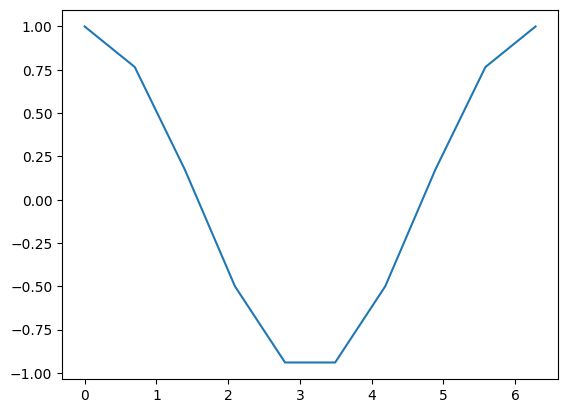

In [4]:
plt.plot(x,y)
plt.show()

Notice that in the x-axis we have a low number of samples (10), which causes this low resolution `cos` plot, we can increase the number of samples to get a higher resolution one.

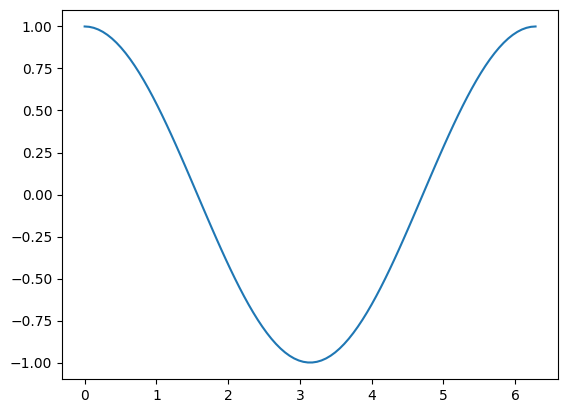

In [5]:
x = np.linspace(0, 2*math.pi, 100)
y = np.cos(x)
plt.plot(x,y)
plt.show()

To show an interactive plot, we could use the magic function `%matplotlib notebook`

In [6]:
%matplotlib notebook
# matplotlib notebook mode activated for interactive plots (zooming, panning, etc.)

In [7]:
x = np.linspace(0, 2*math.pi, 100)
y = np.cos(x)
plt.plot(x,y)
plt.show()

<IPython.core.display.Javascript object>

### Figures

The first building block of `matplotlib` is the figure, a figure is just an empty space that shows plot, for example:

In [8]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title("Cos(x)")
ax.set_xlabel("Angle (Radians)")
ax.set_ylabel("Cos")
ax.grid(True)
ax.plot(x,y)
fig.show()

<IPython.core.display.Javascript object>

Notice how we used `set_tilte`, `set_xlabel`, and `set_ylabel`.

You can use the magic function `%matplotlib inline` to make it inline agine.

In [9]:
%matplotlib inline

### Task 1: Draw `tan` function from -2PI to 2PI with 100 samples resoultion, then draw it again with 1000 samples.

C:\Users\HP\AppData\Local\Temp\ipykernel_25784\2250140636.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


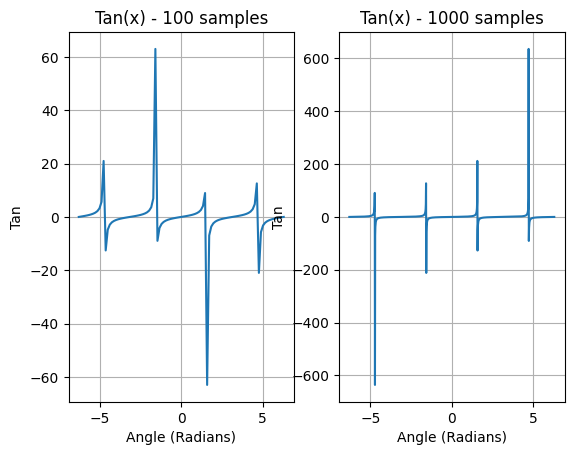

In [10]:
fig = plt.figure()
x = np.linspace(-2*math.pi, 2*math.pi, 100)
y = np.tan(x)
ax = fig.add_subplot(1,2,1)
ax.set_title("Tan(x) - 100 samples")
ax.set_xlabel("Angle (Radians)")
ax.set_ylabel("Tan")
ax.grid(True)
ax.plot(x,y)

x2 = np.linspace(-2*math.pi, 2*math.pi, 1000)
y2 = np.tan(x2)
ax2 = fig.add_subplot(1,2,2)
ax2.set_title("Tan(x) - 1000 samples")
ax2.set_xlabel("Angle (Radians)")
ax2.set_ylabel("Tan")
ax2.grid(True)
ax2.plot(x2,y2)

fig.show()

### Bar Chart
To plot a bar chart you can use the function `plt.bar`, for example:

In [11]:
x = np.array(["Test 1","Test 2", "Test 3"])
y = np.array([10, 5, 15])

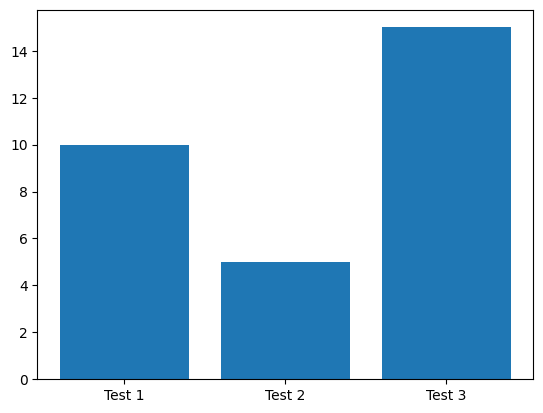

In [12]:
plt.bar(x, y)
plt.show()

### Loading and saving a file using Numpy
You could save an array using `np.save`, and you can load it again using `np.load`, the files will be in a binary format that NumPy could read easily.

In [13]:
test = np.linspace(0, 10, 100)
print(test.shape)
np.save('test_file', test)

(100,)


In [14]:
import os
print("test_file.npy size: "+str(os.path.getsize("test_file.npy")) + " Bytes")

test_file.npy size: 928 Bytes


You can save the data in text format, or load it using `np.savetxt`, `np.loadtxt`.

In [15]:
np.savetxt('test_file.txt', test)

In [16]:
print("test_file.npy size: "+str(os.path.getsize("test_file.txt")) + " Bytes")

test_file.npy size: 2600 Bytes


Notice that the text file need much larger space, and more time to load.

In [17]:
test_from_npy = np.load('test_file.npy')
test_from_txt = np.loadtxt('test_file.txt')
print (np.all(test_from_npy == test_from_txt))

True


### Task 2: Load the file `covid_gaza_data.npy` and plot the covied cases in Gaza Strip as line chart

For the X-axis, you should load the file `covid_gaza_date.npy`.

Notice that the data has 4 columns (Cases, Deaths, Recoveries, Active Cases)

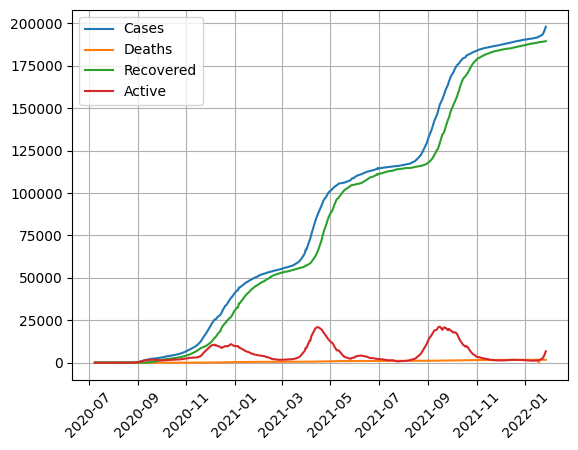

In [30]:
# load data
dates = np.load('covid_gaza_date.npy')
data = np.load('covid_gaza_data.npy')

# plot data
plt.plot(dates, data[:,0], label='Cases')
plt.plot(dates, data[:,1], label='Deaths')
plt.plot(dates, data[:,2], label='Recovered')
plt.plot(dates, data[:,3], label='Active')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### Task 3: Calculate the number of new cases each day, then draw it as a bar chart

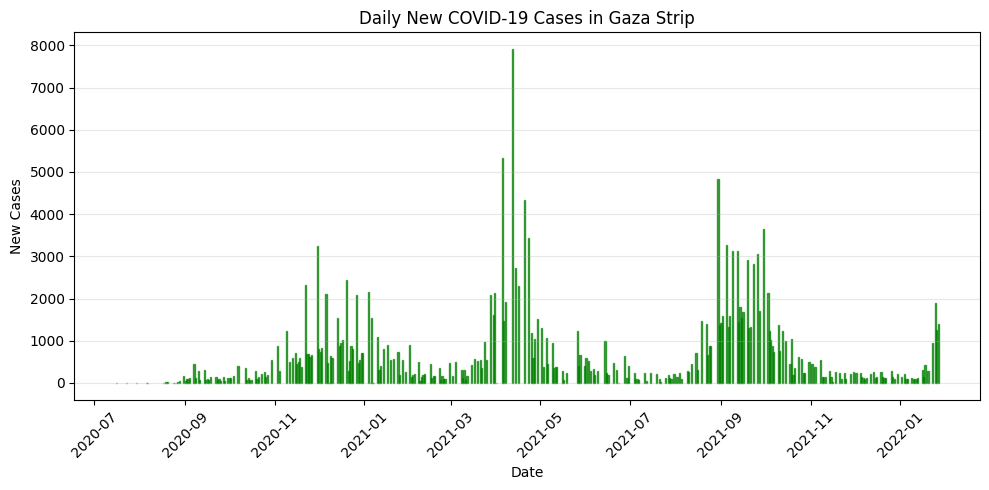

In [31]:
dates = np.load('covid_gaza_date.npy')
data = np.load('covid_gaza_data.npy')

# calculate daily new cases
total_cases = data[:,0] # total cases column
new_cases = total_cases[1:] - total_cases[:-1]

# plot total cases and new cases
plt.figure(figsize=(10,5))
plt.bar(dates[1:], new_cases, color='green', alpha=0.7, edgecolor='green')
plt.title('Daily New COVID-19 Cases in Gaza Strip')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter
As you might expect, we won't always draw linear data we might have data without direct relation between x, y, this data could be visualised using `plt.scatter`, the points in the graph could also have different values (size), or color.

**Note:** This is a very brief introduction to scatters.

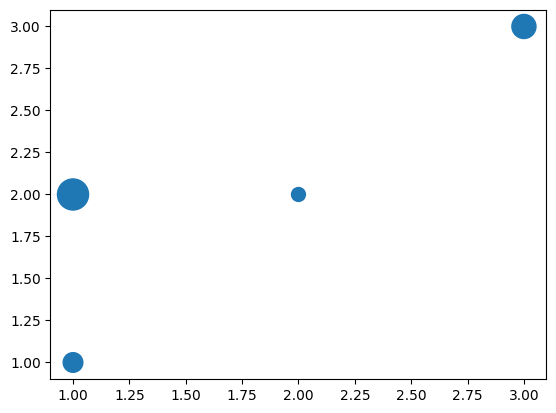

In [20]:
%matplotlib inline
x_test = np.array([1,1,2,3])
y_test = np.array([1,2,2,3])
v_test = np.array([200,500,100,300])
plt.scatter(x_test, y_test, v_test)
plt.show()

Notice that we have two values with the same `x` value at `x=1`.

### Pie Chart
I don't think that anyone needs an introduction to pie charts!

You can draw pie charts using `plt.pie`, for example:

C:\Users\HP\AppData\Local\Temp\ipykernel_25784\3797702315.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


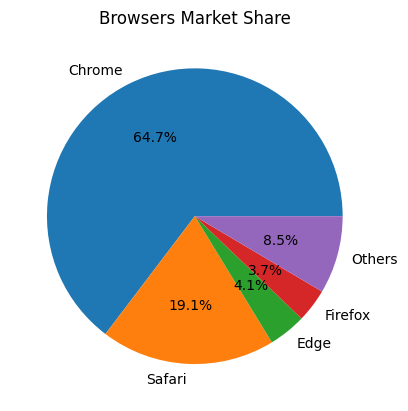

In [21]:
%matplotlib inline
browsers = np.array(["Chrome", "Safari", "Edge", "Firefox", "Others"])
users = np.array([64.67, 19.06, 4.10, 3.66, 8.51])
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.pie(users, labels=browsers, autopct='%1.1f%%')
ax.set_title("Browsers Market Share")
fig.show()

### Drawing A Matrix!
You could draw a matrix using `plt.matshow`, which will show the values of the matrix within a color space, you could show that color space using `plt.colorbar`

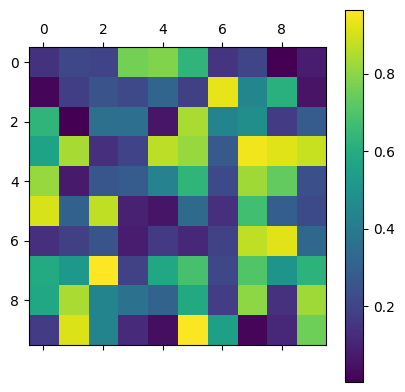

In [22]:
test_matrix = np.random.random((10,10))
plt.matshow(test_matrix)
plt.colorbar()
plt.show()

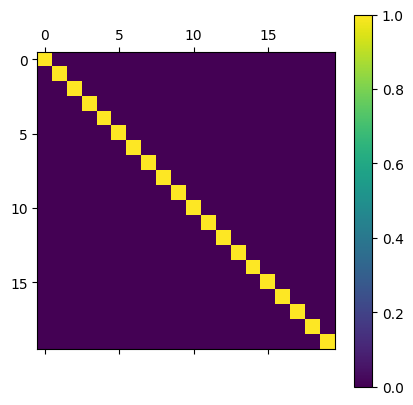

In [23]:
eye_matrix = np.eye(20)
plt.matshow(eye_matrix)
plt.colorbar()
plt.show()

Note, this will be very useful in evaluating your system!

### Subplots
Sometimes, you will need to plot a lot of things together, so you could compare the results between different graphs, you can do this by creating subplots, to create a subplot, you will need to create a figure, then you can add a subplot to it using `add_subplot`, which will take 3 parameters, `number of rows`, `number of columns`, `index of your plot`.

#### Example 1

C:\Users\HP\AppData\Local\Temp\ipykernel_25784\60045313.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


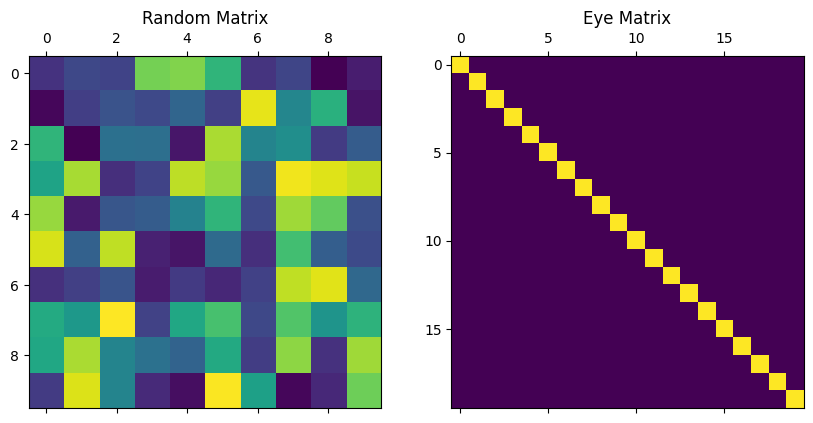

In [24]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.matshow(test_matrix)
ax1.set_title("Random Matrix")
ax2.matshow(eye_matrix)
ax2.set_title("Eye Matrix")
fig.show()

Notice that we adjust the size of the figure using `figsize=(10,5)`.

#### Example 2
You could also use `plt.subplots`, to create a figure and subplots!

C:\Users\HP\AppData\Local\Temp\ipykernel_25784\304382465.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


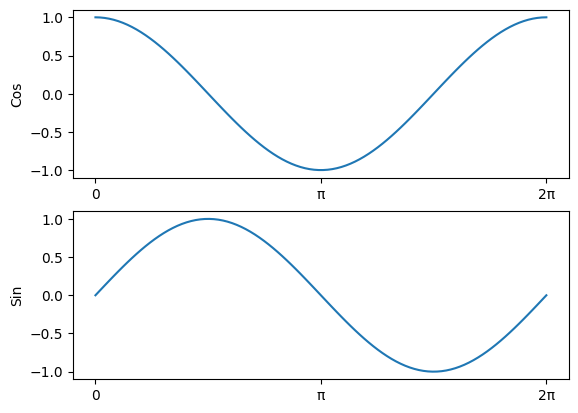

In [25]:
x = np.linspace(0, 2*math.pi, 100)
cos = np.cos(x)
sin = np.sin(x)
fig, axs = plt.subplots(2,1)
axs[0].plot(x, cos)
axs[0].set_ylabel("Cos")
axs[0].set_xticks([0, 3.14, 3.14*2])
axs[0].set_xticklabels(["0", "π", "2π"])
axs[1].plot(x, sin)
axs[1].set_ylabel("Sin")
axs[1].set_xticks([0, 3.14, 3.14*2])
axs[1].set_xticklabels(["0", "π", "2π"])
# You couild use this:
# plt.xticks([0, 3.14, 3.14*2], ["0", "π", "2π"]) 
fig.show()

### Flatten and Reshape
Converting the data from one shape to another is a trivial task using NumPy, you could flatten your matrix using `np.flatten`, or reshape a flat array to a matrix using `np.reshape`.

Reshaping an array is not always a trivial task, you might need to swap some axes using `np.swapaxes`.

#### Example: We can use reshape to convert our linear data of a website visitors to a matrix that divides it by weeks.

Data shape: (91,)
Data new shape: (13, 7)


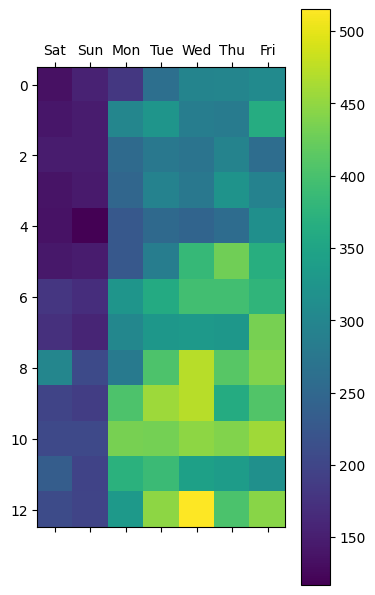

In [26]:
visitors = np.load('visitors.npy')
print("Data shape: "+str(visitors.shape))
visitors_reshaped = np.reshape(visitors,(13,7))
print("Data new shape: "+str(visitors_reshaped.shape))
plt.matshow(visitors_reshaped)
plt.xticks(range(0,7), ["Sat", "Sun", "Mon", "Tue", "Wed", "Thu", "Fri"])
plt.colorbar()
plt.show()

<center>
    <h4>End of Lab 2</h4>
</center>